Se propone simular el siguiente teorema: Poblaciones normales independientes con varianza conocida, el cual aprendí el curso pasado en la asignatura de Inferencia Estadistica del grado de matemáticas (soy alumno de la doble titulación)

# Teorema
Sean 
$$ 
(X_1, \dots, X_n) , (Y_1, \dots, Y_m)
$$
dos secuencias de variables aleatorias independientes 
con distribución 

$$
X \sim N(\mu_X, \sigma_X^2), \quad Y \sim N(\mu_Y, \sigma_Y^2)
$$

independientes. Entonces:

$$
\frac{\overline{X} - \overline{Y} - (\mu_X - \mu_Y)}
{\sqrt{\tfrac{\sigma_X^2}{n} + \tfrac{\sigma_Y^2}{m}}}
\;\sim\; N(0,1)
$$


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def simulate_z(muX, sigmaX, n, muY, sigmaY, m, Nsim=10000, bins=40):
    """
    Simula el estadístico Z para dos medias normales con varianzas conocidas
    y compara el histograma con la distribución N(0,1).

    Args:
        muX (float): media poblacional de X
        sigmaX (float): desviación típica de X
        n (int): tamaño muestral de X
        muY (float): media poblacional de Y
        sigmaY (float): desviación típica de Y
        m (int): tamaño muestral de Y
        Nsim (int): número de simulaciones
        bins (int): número de intervalos del histograma

    Return: media de Z y desviación típica de Z
    """
    # Simular medias muestrales
    Xbar = np.mean(np.random.normal(muX, sigmaX, (Nsim, n)), axis=1)
    Ybar = np.mean(np.random.normal(muY, sigmaY, (Nsim, m)), axis=1)

    # Estadístico Z
    Z = (Xbar - Ybar - (muX - muY)) / np.sqrt(sigmaX**2/n + sigmaY**2/m)

    # Gráfica
    plt.figure(figsize=(8,5))
    plt.hist(Z, bins=bins, density=True, alpha=0.6, color="skyblue", label="Simulación")
    x = np.linspace(-4,4,300)
    plt.plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label="N(0,1)")
    plt.title("Distribución simulada del estadístico Z")
    plt.xlabel("Z")
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Retorna datos útiles
    return {
        "media_Z": np.mean(Z),
        "desv_Z": np.std(Z),
    }




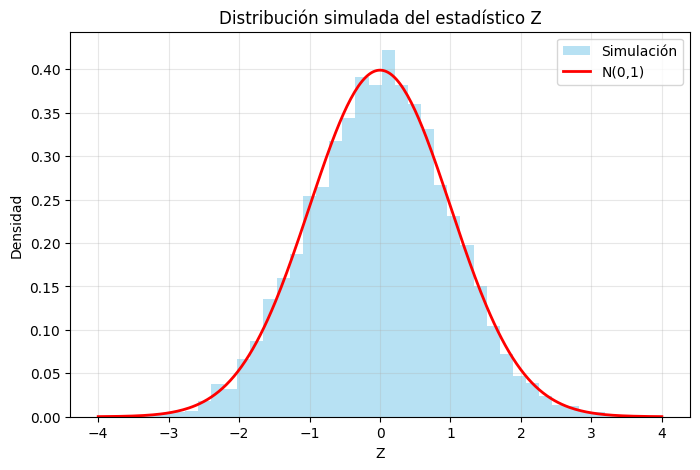

Media simulada de Z: -0.0030351869449013777
Desviación típica simulada de Z: 0.9951904723250395
Se observa lo esperado, la distribucion que se sigue 
es una NORMAL de MEDIA 0 y DESVIACION TIPICA 1


In [26]:
res = simulate_z(muX=5, sigmaX=2, n=50,
                 muY=4, sigmaY=3, m=60,
                 Nsim=10000)

print("Media simulada de Z:", res["media_Z"])
print("Desviación típica simulada de Z:", res["desv_Z"])
print("Se observa lo esperado, la distribucion que se sigue \nes una NORMAL de MEDIA 0 y DESVIACION TIPICA 1")
